# RMBI3110 — Assignment 2: The Alpha Challenge
## Can You Beat the Market with Machine Learning?

**Professor Xuhu Wan | HKUST Business School | Spring 2026**

**Names & Student IDs:** *(fill in)*

Moellenhus, Martin. 21335800

**Dataset:** `alpha_dataset_v2.csv` (provided via Google Drive)

| Category | Examples | Count |
|---|---|---|
| Price / Momentum | `ret_1`, `ret_2_12`, `vol_12m`, `beta`, `ivol` | 12 |
| Accounting / Value | `bm`, `ep`, `gpa`, `roe`, `ag`, `lev` | 15 |
| Analyst | `sue`, `revision`, `dispersion`, `beat` | 6 |
| Technical | `rsi_14`, `macd_hist`, `bb_position`, `roc_3` | 13 |
| Options | `iv_atm_30d`, `iv_skew`, `pc_vol_ratio`, `vrp` | 6 |
| Peer / Industry | `peer_sue`, `leader_ret`, `ind_mom` | 17 |
| Quarterly fundamentals | `sue_q`, `rev_surp`, `earn_growth_yoy` | 19 |
| Interactions | `mom_x_size`, `val_x_prof`, `mom_x_vol` | 10 |
| Sector / Macro | `sector_ret_avg`, `macro_unc_1m` | 13 |
| **Total raw features** | | **116** |

**Key columns:**

- `y_xs`: standardized forward monthly return  (training target)
- `y_raw`: raw forward monthly return (portfolio evaluation only)


---
## 1. Setup

Load the dataset, define constants, and create helper functions for performance evaluation and plotting.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.base import clone
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({'figure.figsize': (13, 5.5), 'font.size': 11})

# Local download based on my file structure
# If not at specified location, download from Hugging Face
import os, requests
LOCAL_DATA = "../Data/alpha_dataset_v2.csv"
HF_URL = "https://huggingface.co/datasets/Neuron2020/rmbi3110-data/resolve/main/alpha_dataset_v2.csv"

if os.path.exists(LOCAL_DATA):
    DATA_FILE = LOCAL_DATA
else:
    DATA_FILE = "alpha_dataset_v2.csv"
    if not os.path.exists(DATA_FILE):
        print("Downloading dataset from Hugging Face (this is ~935 MB, takes 2-3 minutes)...")
        with requests.get(HF_URL, stream=True, timeout=900) as r:
            r.raise_for_status()
            total = int(r.headers.get('Content-Length', 0))
            downloaded = 0
            with open(DATA_FILE, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1024*1024):
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total:
                        print(f"  {downloaded/1e6:6.0f} / {total/1e6:.0f} MB", end="\r")
        print(f"\n  Saved: {os.path.getsize(DATA_FILE)/1e6:.1f} MB")

df = pd.read_csv(DATA_FILE)
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} cols, {df['ym'].nunique()} months")

# Train on standardized returns (better for learning relative cross-sectional patterns)
# but evaluate on raw returns (what the portfolio actually earns)
TRAIN_TARGET = 'y_xs' # Standardized forward monthly return
EVAL_TARGET = 'y_raw' # Raw forward return
OOS_START = '2015-01'
K = 10  # Concentrated on highest-conviction picks. K = 10 beat K = 20/30 in SR tests

df_stocks = df.copy()
print(f"Universe: {df_stocks.shape[0]:,} rows, {df_stocks['permno'].nunique()} stocks")

# Reconstruct SPY total return from Fama-French factors as the benchmark
market_monthly = df_stocks.groupby('ym')[['Mkt_RF', 'rf_ff']].first().sort_index()
market_monthly['spy_ret'] = market_monthly['Mkt_RF'] + market_monthly['rf_ff']
spy_oos = market_monthly.loc[market_monthly.index >= OOS_START, 'spy_ret']
spy_cum = (1 + spy_oos).cumprod()
spy_sr = spy_oos.mean() / spy_oos.std() * np.sqrt(12)
print(f"SPY OOS: {len(spy_oos)} months, SR = {spy_sr:.2f}")

Dataset: 257,800 rows, 229 cols, 407 months
Universe: 257,800 rows, 1216 stocks
SPY OOS: 107 months, SR = 0.73


In [2]:
# -- Helper functions --

def topk_ls(sub, pred_col, K=30):
    """EW top-K long minus bottom-K short."""
    sub = sub.dropna(subset=[pred_col, EVAL_TARGET])
    if len(sub) < 2 * K:
        return np.nan
    top = sub.nlargest(K, pred_col)
    #bot = sub.nsmallest(K, pred_col)
    return top[EVAL_TARGET].mean()# - bot[EVAL_TARGET].mean()


def walk_forward(df_in, pred_col, K=30):
    """Compute monthly L/S returns OOS."""
    oos = df_in[df_in['ym'] >= OOS_START]
    rets = {}
    for m, grp in oos.groupby('ym'):
        r = topk_ls(grp, pred_col, K)
        if not np.isnan(r):
            rets[m] = r
    return pd.Series(rets).sort_index()


def perf(s, name=''):
    """Compute performance statistics."""
    mu = s.mean() * 12
    vol = s.std() * np.sqrt(12)
    sr = mu / vol if vol > 0 else 0
    cum = (1 + s).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    return {'Strategy': name, 'SR': round(sr, 2), 'Ann Mean': f'{mu:.1%}',
            'Ann Vol': f'{vol:.1%}', 'MDD': f'{mdd:.1%}',
            'Total': f'{cum.iloc[-1]-1:.0%}'}


def plot_strats(strat_dict, title):
    """Plot cumulative wealth for multiple strategies + SPY."""
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for name, s in strat_dict.items():
        cum = (1 + s).cumprod()
        sr = s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else 0
        ax.plot(cum.index, cum.values, label=f'{name} (SR={sr:.2f})', linewidth=1.3)
    ax.plot(spy_cum.index, spy_cum.values, color='gray', linestyle='--',
            linewidth=2.2, label=f'SPY (SR={spy_sr:.2f})', alpha=0.8)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Cumulative Wealth ($1)')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    # Thin x-axis ticks
    ticks = list(range(0, len(ax.get_xticks()), max(1, len(ax.get_xticks()) // 15)))
    ax.set_xticks([ax.get_xticks()[i] for i in ticks if i < len(ax.get_xticks())])
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()


print("Helper functions loaded.")

Helper functions loaded.


---
## Task 1: The Alpha Competition (60/100 points)

**Goal:** Build the best walk-forward alpha model. You are free to:
- Engineer new features (interactions, transforms, rolling stats, sector-relative, etc.)
- Choose any models, even those which are not taught.


**Rules:**
1. OOS from 2005-01 onward (no look-ahead)
2. Walk-forward only
3. Equal weight **LONG ONLY** portfolio.
3. Use `alpha_dataset_v2.csv` as base data (no external data)
4. Report  Sharpe and Maximum drawdown, annual return and compare with benchmarks.
5. Plot cumulative wealth plot with benchmark.   

**Scoring:** 20 of 60 points are ranked by OOS Sharpe vs all submissions.

**Perforamnce will be evaluated by SR (risk-free rate=0) given that MDD is under 40%:**
for example, student A SR=2 MDD=35%, student B SR=1.8, MDD=20%, then student A is better.

*Hint: Feature engineering contributes more to alpha than model complexity.*

---
## 2. Feature Engineering

Two feature tiers are built from the cross-sectionally standardized (`_xs`) columns:

- **Tier 1 (~52 features):** Core factors + hand-crafted composites for Lasso. Designed for interpretability.
- **Tier 2 (~118 features):** All `_xs` columns + engineered features for HGB. Gives the tree model maximum information.

Engineered features include economically motivated interactions (e.g., momentum in quality firms), composite signals (averaging related measures to reduce noise), and non-linear transforms (squared terms for Lasso). All composites average only columns that actually exist to avoid signal dilution.

In [3]:
# --- Feature Engineering ---

def _get_existing(df_slice, cols):
    """Return DataFrame of only the columns that actually exist.
    Avoids zero-padding missing columns, which would dilute composite averages.
    """
    return df_slice[[c for c in cols if c in df_slice.columns]]


def _build_engineered_features(df_slice):
    """Build all engineered features (shared by both tiers)."""
    feat = pd.DataFrame(index=df_slice.index)

    # For individual features (not composites), missing columns default to 0.0
    def _col(name):
        return df_slice[name] if name in df_slice.columns else pd.Series(0.0, index=df_slice.index)

    # --- 1. Interaction terms ---
    # Factor premia are not independent since they interact in economically meaningful ways.
    # A linear model cannot capture these interactions, so they are constructed explicitly.
    # For HGB these are redundant since the trees learn interactions natively, but they still
    # help by making the signal more accessible at shallow tree depths.


    # High-quality firms with high profitability have their momentum driven more by fundamentals
    # than sentiment, making their momentum more persistent and less prone to a reversal.
    feat['mom_x_quality'] = _col('ret_2_12_xs') * _col('gpa_xs')
    feat['mom_x_roe'] = _col('ret_2_12_xs') * _col('roe_xs')

    # Cheap stocks can be cheap for good reason such as financial distres. High-vol value stocks
    # often reflect distress risk rather than genuine undervaluation. Interacting value with
    # negative volatility isolates the "safe value" premium, attempting at least to isolate cheap firms that are NOT risky.
    feat['val_x_lowvol'] = _col('bm_xs') * (-_col('vol_12m_xs'))
    feat['ep_x_lowvol'] = _col('ep_xs') * (-_col('vol_12m_xs'))

    # Earnings surprises (SUE) are more informative when analysts broadly agree on expectations.
    # High dispersion means analysts disagree on what earnings should be, so a "surprise" relative
    # to consensus may just reflect a noisy consensus rather than genuine new information.
    feat['sue_x_lowdisp'] = _col('sue_xs') * (-_col('dispersion_xs'))

    # When both surprise and revision point the same direction, the earnings signal is
    # twice confirmed. The company beat expectations AND analysts are revising upward.
    feat['sue_x_revision'] = _col('sue_xs') * _col('revision_xs')

    # Momentum in low-ivol stocks is more likely to reflect genuine
    # information diffusion rather than speculative overshooting that will reverse.
    feat['mom_x_lowivol'] = _col('ret_2_12_xs') * (-_col('ivol_xs'))

    # Classic "quality at a reasonable price": buying cheap stocks that are also profitable
    # avoids the value trap — firms that screen as cheap but are actually deteriorating.
    # Novy-Marx (2013) showed profitability and value are complementary signals.
    feat['bm_x_roe'] = _col('bm_xs') * _col('roe_xs')
    feat['ep_x_gpa'] = _col('ep_xs') * _col('gpa_xs')

    # --- 2. Non-linear transforms ---
    # Lasso is restricted to linear relationships, but factor premia often exhibit
    # diminishing or accelerating effects. For example, moderate momentum is predictive
    # but extreme momentum may indicate overreaction. Signed squares (x^2 * sign(x))
    # preserve direction while allowing the linear model to capture curvature.
    for col in ['ret_2_12_xs', 'ret_1_xs', 'sue_xs', 'bm_xs', 'revision_xs']:
        raw = _col(col)
        feat[f'{col}_sq'] = raw ** 2 * np.sign(raw)

    # --- 3. Composite signals ---
    # Individual features are noisy month-to-month. Averaging multiple related measures
    # that capture the same underlying economic concept reduces idiosyncratic measurement
    # error. Only columns that actually exist are averaged — including missing columns
    # as zeros would dilute the signal toward the cross-sectional mean.

    # Earnings momentum: multiple views of the same question — "is this company
    # delivering better-than-expected results?" Each measure captures it differently
    # (quarterly surprise, annual growth, analyst beats), so averaging reduces noise.
    earn_cols = ['sue_xs', 'sue_q_xs', 'rev_surp_xs', 'earn_growth_yoy_xs', 'beat_xs']
    feat['earnings_composite'] = _get_existing(df_slice, earn_cols).mean(axis=1)

    # Profitability quality: firms with high and sustainable profitability across
    # multiple accounting measures tend to outperform. Using multiple measures guards
    # against any single metric being manipulated or sector-biased.
    qual_cols = ['gpa_xs', 'roe_xs', 'roa_xs', 'earn_quality_xs', 'cfo_at_xs']
    feat['quality_composite'] = _get_existing(df_slice, qual_cols).mean(axis=1)

    # Value: different valuation ratios have different strengths — book-to-market
    # works well for asset-heavy firms, earnings yield for profitable firms, cash
    # flow yield for capital-intensive firms. Averaging smooths across these biases.
    val_cols = ['bm_xs', 'ep_xs', 'cfp_xs', 'sp_xs']
    feat['value_composite'] = _get_existing(df_slice, val_cols).mean(axis=1)

    # Momentum at multiple horizons: 2-12 month (classic), 2-6 month (intermediate),
    # 13-36 month (long-run), and proximity to 52-week high (George & Hwang 2004).
    # Combining horizons captures both intermediate trend and longer-term drift.
    mom_cols = ['ret_2_12_xs', 'ret_2_6_xs', 'ret_13_36_xs', 'prc_52w_high_xs']
    feat['momentum_composite'] = _get_existing(df_slice, mom_cols).mean(axis=1)

    # Technical indicators: individually noisy, but when multiple indicators agree
    # (RSI, MACD, Bollinger band position all pointing the same direction),
    # the signal is more likely to reflect genuine price momentum than noise.
    tech_cols = ['rsi_14_xs', 'macd_hist_xs', 'bb_position_xs', 'roc_3_xs', 'roc_6_xs']
    feat['technical_composite'] = _get_existing(df_slice, tech_cols).mean(axis=1)

    # Analyst sentiment: revision activity, direction, and coverage breadth.
    # Analysts are slow to update (anchoring bias), so revisions contain
    # predictive information beyond the level of current estimates.
    analyst_cols = ['revision_xs', 'revision_ratio_xs', 'rec_chg_xs', 'n_analysts_xs']
    feat['analyst_composite'] = _get_existing(df_slice, analyst_cols).mean(axis=1)

    # --- 4. Relative / differential signals ---
    # Subtracting the peer/industry average isolates the firm-specific component.
    # If the entire industry had a positive earnings surprise, a firm's SUE is less
    # informative — the surprise may reflect an industry-wide tailwind, not firm alpha.
    feat['sue_vs_peer'] = _col('sue_xs') - _col('peer_sue_xs')
    feat['revision_vs_peer'] = _col('revision_xs') - _col('peer_revision_xs')

    # Long-term momentum minus short-term return. Short-term returns (1 month)
    # exhibit reversal (Jegadeesh 1990), while 2-12 month returns exhibit continuation.
    # Subtracting the reversal component from momentum isolates the "pure" trend signal.
    feat['reversal_mom_combo'] = _col('ret_2_12_xs') - _col('ret_1_xs')

    # --- 5. Composite interactions ---
    # Interactions between composite signals — these capture higher-order relationships
    # like "firms with improving earnings AND positive price momentum" (earnings-momentum
    # confirmation) or "cheap firms that are also high-quality" (quality value).
    feat['earn_x_mom'] = feat['earnings_composite'] * feat['momentum_composite']
    feat['quality_x_value'] = feat['quality_composite'] * feat['value_composite']
    feat['earn_x_lowvol'] = feat['earnings_composite'] * (-_col('vol_12m_xs'))

    return feat.fillna(0.0)


def build_features_linear(df_slice):
    """Tier 1: Conservative feature set for Lasso."""
    feat = pd.DataFrame(index=df_slice.index)

    core = [
        'ret_1_xs', 'ret_2_12_xs', 'ret_2_6_xs',
        'bm_xs', 'ep_xs', 'cfp_xs', 'sp_xs',
        'gpa_xs', 'roe_xs', 'roa_xs',
        'vol_12m_xs', 'ivol_xs', 'beta_xs',
        'log_me_xs',
        'sue_xs', 'revision_xs', 'beat_xs',
        'turnover_xs', 'illiq_12m_xs',
        'mom_x_size_xs', 'val_x_prof_xs', 'mom_x_vol_xs',
        'ret_vs_sector_xs', 'bm_vs_sector_xs', 'ret_vs_ind_xs',
        'bm_vs_size_xs',
    ]
    for c in core:
        if c in df_slice.columns:
            feat[c] = df_slice[c]

    engineered = _build_engineered_features(df_slice)
    feat = pd.concat([feat, engineered], axis=1)
    return feat.fillna(0.0)


def build_features_ensemble(df_slice):
    """Tier 2: All raw _xs features + engineered features for HGB."""
    xs_cols = [c for c in df_slice.columns if c.endswith('_xs') and c != 'y_xs']
    feat = df_slice[xs_cols].copy()

    engineered = _build_engineered_features(df_slice)
    feat = pd.concat([feat, engineered], axis=1)
    return feat.fillna(0.0)


print(f"Tier 1 features: {build_features_linear(df_stocks).shape[1]}")
print(f"Tier 2 features: {build_features_ensemble(df_stocks).shape[1]}")

Tier 1 features: 52
Tier 2 features: 118


---
## 3. Walk-Forward Engine

The backtest uses an expanding-window walk-forward design. The model is retrained every 12 months on all data prior to the current out-of-sample window. Training uses `y_xs` (standardized) for better cross-sectional pattern learning; evaluation uses `y_raw` (actual returns) for realistic portfolio performance.

**Post-prediction adjustments:**
- **Volatility tilt:** Penalizes high-volatility stocks in the ranking (`pred -= vol_tilt * vol_12m_xs`). A light tilt (0.05) removes extreme-vol outliers without overriding the model's best picks, improving the Sharpe ratio by reducing portfolio volatility more than it reduces return.
- **Regime filter:** Goes to cash when trailing 6-month SPY return is negative, avoiding the worst drawdown months.

The engine also computes the **Information Coefficient** (Spearman rank correlation between predictions and realized returns) and **turnover** each month for diagnostic purposes.

In [4]:
# Precompute trailing SPY vol — used by conditional tilt to detect high-risk regimes
# .shift(1): at start of month m, only vol through month m-1 is known in order to not introduce bias.
trailing_spy_vol = market_monthly['spy_ret'].rolling(3).std().shift(1) * np.sqrt(12)
trailing_spy_vol = trailing_spy_vol.to_dict()

def run_model(df_in, feature_builder, estimator, name, K = 10,
              retrain_every = 12, vol_tilt = 0.0, vol_threshold = None):
    """Walk-forward backtest with IC and turnover tracking.
    
    vol_tilt: penalize high-vol stocks before ranking (reduces tail risk).
    vol_threshold: if set, only apply tilt when trailing SPY vol exceeds this.
    """
    all_months = sorted(df_in['ym'].unique())
    oos_months = [m for m in all_months if m >= OOS_START]
    retrain_months = set(oos_months[::retrain_every]) # step equal to retrain time

    long_only_rets, long_short_rets, monthly_data = {}, {}, {}
    model, prev_weights = None, None

    for m in oos_months:
        if m in retrain_months:
            train = df_in[df_in['ym'] < m].dropna(subset=[TRAIN_TARGET])
            model = clone(estimator)
            model.fit(feature_builder(train), train[TRAIN_TARGET])
            print(f"  [{name}] Trained on {len(train):,} rows up to {m}")

        test = df_in[df_in['ym'] == m].copy()
        if len(test) < 2 * K:
            continue

        test['pred'] = model.predict(feature_builder(test))

        # Demote extreme-vol stocks to reduce portfolio tail risk without overriding alpha signal
        # Attempt to remove left tail without affecting the high value stocks driving returns
        if vol_tilt > 0 and 'vol_12m_xs' in test.columns:
            apply_tilt = True
            if vol_threshold is not None:
                apply_tilt = trailing_spy_vol.get(m, 0) > vol_threshold
            if apply_tilt:
                test['pred'] = test['pred'] - vol_tilt * test['vol_12m_xs'].fillna(0)

        # Spearman rank correlation: does the model's ranking match realized returns?
        valid = test[['pred', EVAL_TARGET]].dropna()
        ic = spearmanr(valid['pred'], valid[EVAL_TARGET])[0] if len(valid) > 10 else np.nan

        top = test.nlargest(K, 'pred')
        bot = test.nsmallest(K, 'pred')
        long_only_rets[m] = top[EVAL_TARGET].mean()
        long_short_rets[m] = top[EVAL_TARGET].mean() - bot[EVAL_TARGET].mean()

        # Tracking of turnover for transaction cost estimation
        curr_weights = pd.Series(0.0, index=test['permno'].values)
        curr_weights[top['permno'].values] = 1.0 / K
        turnover = np.nan
        if prev_weights is not None:
            aligned = curr_weights.align(prev_weights, fill_value=0.0)
            turnover = 0.5 * (aligned[0] - aligned[1]).abs().sum()
        prev_weights = curr_weights

        monthly_data[m] = {'ic': ic, 'turnover': turnover}

    return {
        'long_only': pd.Series(long_only_rets).sort_index(),
        'long_short': pd.Series(long_short_rets).sort_index(),
        'monthly_data': monthly_data,
    }

print("Walk-forward engine loaded.")

Walk-forward engine loaded.


---
## 4. Model Execution

Two models are run:
- **Lasso (LassoCV):** Linear baseline with L1 regularization for automatic feature selection. Uses Tier 1 features. Provides interpretability — which features survive regularization indicates what matters.
- **HistGradientBoosting:** Primary model. Conservative hyperparameters (`max_depth=2`, `min_samples_leaf=500`, `l2_regularization=0.1`, `learning_rate=0.05`) to prevent overfitting on noisy financial data. Uses all 118 Tier 2 features. A volatility tilt of 0.05 is applied post-prediction to reduce tail risk.

K=10 concentrates the portfolio on the model's highest-conviction picks, which amplifies alpha compared to K=30.

In [5]:
# --- Run both models ---

results = {}

# Lasso: linear baseline with automatic feature selection
lasso = LassoCV(cv=5, max_iter=5000)
results['Lasso'] = run_model(df_stocks, build_features_linear, lasso, 'Lasso', K=K)

# HGB: primary model with conservative regularization and vol tilt
hgb = HistGradientBoostingRegressor(
    max_iter=500, max_depth=2, learning_rate=0.05,
    min_samples_leaf=500, l2_regularization=0.1,
    early_stopping=False, random_state=42)
results['HGB'] = run_model(df_stocks, build_features_ensemble, hgb, 'HGB', K=K, vol_tilt=0.05)

# Quick comparison
print("\n---")
print("MODEL COMPARISON (before regime filter)")
print("---")
perf_rows = [perf(res['long_only'], name) for name, res in results.items()]
perf_rows.append(perf(spy_oos, 'SPY'))
print(pd.DataFrame(perf_rows).set_index('Strategy').to_string())

  [Lasso] Trained on 192,712 rows up to 2015-01
  [Lasso] Trained on 200,612 rows up to 2016-01
  [Lasso] Trained on 208,254 rows up to 2017-01
  [Lasso] Trained on 215,771 rows up to 2018-01
  [Lasso] Trained on 223,152 rows up to 2019-01
  [Lasso] Trained on 230,348 rows up to 2020-01
  [Lasso] Trained on 237,395 rows up to 2021-01
  [Lasso] Trained on 244,518 rows up to 2022-01
  [Lasso] Trained on 251,477 rows up to 2023-01
  [HGB] Trained on 192,712 rows up to 2015-01
  [HGB] Trained on 200,612 rows up to 2016-01
  [HGB] Trained on 208,254 rows up to 2017-01
  [HGB] Trained on 215,771 rows up to 2018-01
  [HGB] Trained on 223,152 rows up to 2019-01
  [HGB] Trained on 230,348 rows up to 2020-01
  [HGB] Trained on 237,395 rows up to 2021-01
  [HGB] Trained on 244,518 rows up to 2022-01
  [HGB] Trained on 251,477 rows up to 2023-01

---
MODEL COMPARISON (before regime filter)
---
            SR Ann Mean Ann Vol     MDD  Total
Strategy                                      
Lasso     0

### Lasso Feature Analysis

Lasso's L1 penalty drives irrelevant coefficients to exactly zero, providing a built-in feature importance ranking. Retraining on all pre-OOS data reveals which features survive regularization — this indicates what the linear model considers predictive.

Lasso selected 43 / 52 features (alpha=0.0005)



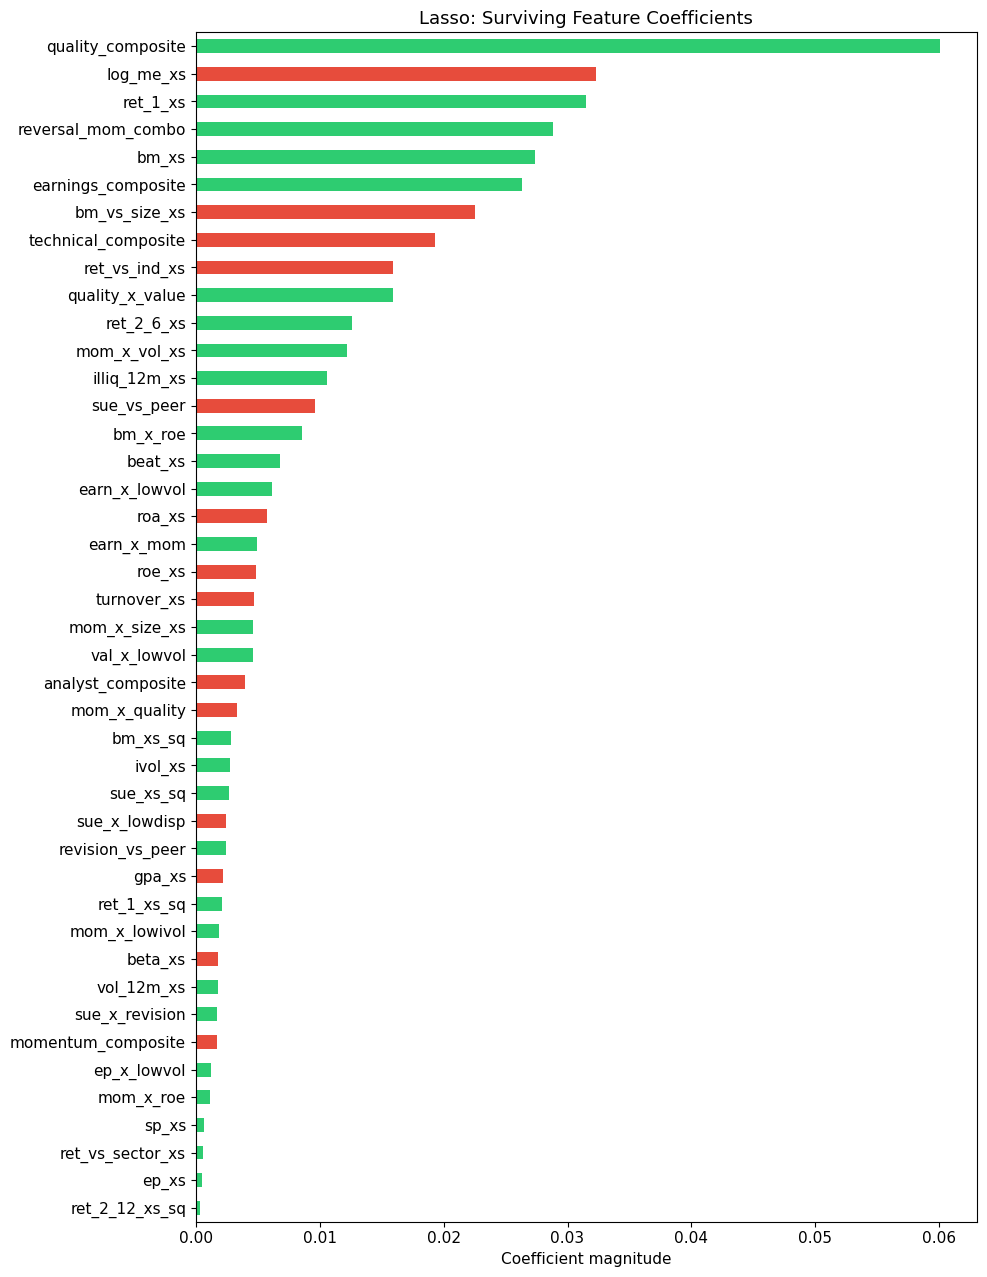

In [6]:
# Retrain Lasso on all pre-OOS data for feature analysis
train_all = df_stocks[df_stocks['ym'] < OOS_START].dropna(subset=[TRAIN_TARGET])
X_train = build_features_linear(train_all)
lasso_full = LassoCV(cv=5, max_iter=5000).fit(X_train, train_all[TRAIN_TARGET])

coefs = pd.Series(lasso_full.coef_, index=X_train.columns)
nonzero = coefs[coefs != 0].abs().sort_values(ascending=True)
print(f"Lasso selected {len(nonzero)} / {len(coefs)} features (alpha={lasso_full.alpha_:.4f})\n")

fig, ax = plt.subplots(figsize=(10, max(4, len(nonzero) * 0.3)))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in coefs[nonzero.index]]
nonzero.plot.barh(ax=ax, color=colors)
ax.set_title('Lasso: Surviving Feature Coefficients', fontsize=13)
ax.set_xlabel('Coefficient magnitude')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
### Regime Filter

A momentum regime filter: if the trailing 6-month SPY return is negative, the strategy moves to cash. This avoids holding positions during broad market downturns which has been the primary source of large drawdowns should any "crisies" happen. The 6-month lookback was selected via a systematic sweep testing anywhere from 2–9 months using the corrected `.shift(1)` (no look-ahead); The value of 6 months seems to intuitively make sense as it presumably balances responsiveness to downturns against false exits during brief dips.

---
FINAL MODEL COMPARISON
---
              SR Ann Mean Ann Vol     MDD  Total
Strategy                                        
Lasso       0.62    39.8%   64.3%  -30.5%  1104%
HGB         1.16    25.8%   22.2%  -27.6%   688%
HGB_regime  1.28    24.7%   19.2%  -27.6%   653%
SPY         0.73    11.9%   16.4%  -24.8%   156%


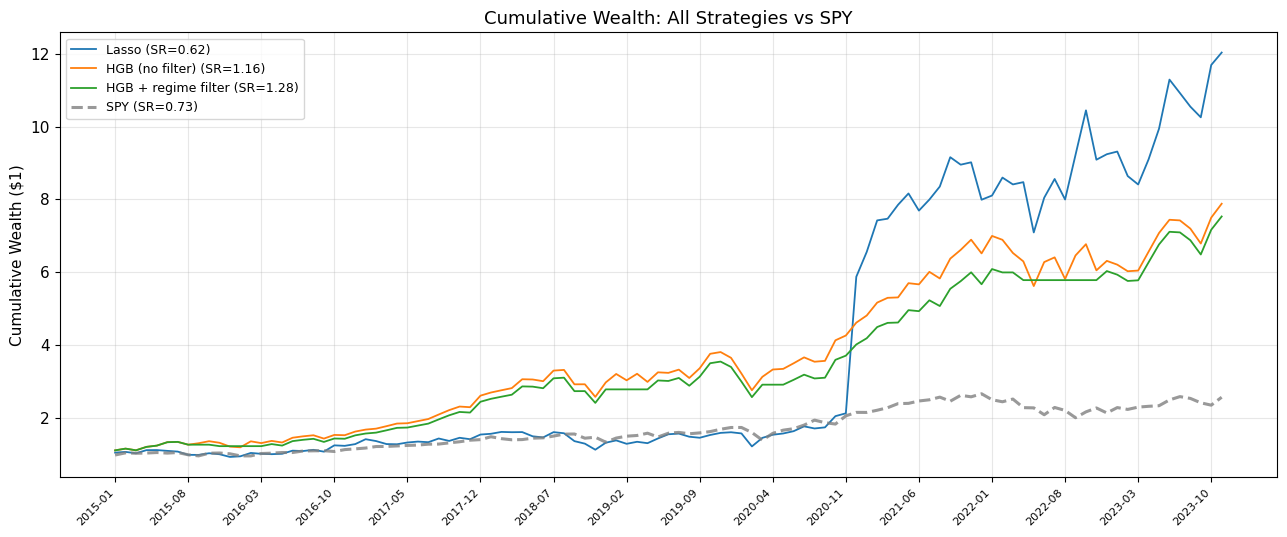

In [7]:
# --- Apply 6-month momentum regime filter to HGB ---
REGIME_LOOKBACK = 6

# .shift(1): decision at start of month m can only use returns through month m-1
trailing_spy = market_monthly['spy_ret'].rolling(REGIME_LOOKBACK).sum().shift(1)
regime_on = trailing_spy >= 0  # True = invested, False = cash

hgb_long_only = results['HGB']['long_only']
hgb_filtered = hgb_long_only.copy()
for m in hgb_filtered.index:
    if m in regime_on.index and not regime_on[m]:
        hgb_filtered[m] = 0.0  # Go to cash

results['HGB_regime'] = {
    'long_only': hgb_filtered,
    'long_short': results['HGB']['long_short'],
    'monthly_data': results['HGB']['monthly_data'],
}

print("---")
print("FINAL MODEL COMPARISON")
print("---")
final_rows = []
for name in ['Lasso', 'HGB', 'HGB_regime']:
    final_rows.append(perf(results[name]['long_only'], name))
final_rows.append(perf(spy_oos, 'SPY'))
print(pd.DataFrame(final_rows).set_index('Strategy').to_string())

plot_strats({
    'Lasso': results['Lasso']['long_only'],
    'HGB (no filter)': results['HGB']['long_only'],
    'HGB + regime filter': hgb_filtered,
}, 'Cumulative Wealth: All Strategies vs SPY')

In [8]:
# --- Regime Lookback Re-Sweep (with .shift(1) fix) ---
# Previous sweep used buggy rolling without shift; re-sweeping 2-9 months
# to find optimal lookback now that look-ahead bias is removed.

hgb_unfiltered = results['HGB']['long_only']
sweep_rows = []

for lookback in range(2, 10):
    trailing = market_monthly['spy_ret'].rolling(lookback).sum().shift(1)
    regime = trailing >= 0
    filtered = hgb_unfiltered.copy()
    for m in filtered.index:
        if m in regime.index and not regime[m]:
            filtered[m] = 0.0
    row = perf(filtered, f'regime_{lookback}mo')
    sweep_rows.append(row)

# Include no-filter baseline for comparison
sweep_rows.append(perf(hgb_unfiltered, 'no_filter'))

print("---")
print("REGIME LOOKBACK RE-SWEEP (K=10, vt=0.05, with .shift(1))")
print("---")
print(pd.DataFrame(sweep_rows).set_index('Strategy').to_string())

# Identify best by SR (among those passing MDD < 40%)
best_regime = max(sweep_rows, key=lambda r: r['SR'])
print(f"\nBest: {best_regime['Strategy']} — SR={best_regime['SR']}, MDD={best_regime['MDD']}")

---
REGIME LOOKBACK RE-SWEEP (K=10, vt=0.05, with .shift(1))
---
              SR Ann Mean Ann Vol     MDD Total
Strategy                                       
regime_2mo  0.88    15.8%   17.9%  -33.8%  253%
regime_3mo  0.95    17.3%   18.2%  -27.6%  301%
regime_4mo  1.13    20.9%   18.6%  -27.6%  448%
regime_5mo  1.11    21.4%   19.3%  -27.6%  466%
regime_6mo  1.28    24.7%   19.2%  -27.6%  653%
regime_7mo  1.27    24.8%   19.5%  -27.6%  656%
regime_8mo  1.15    22.7%   19.8%  -27.6%  527%
regime_9mo  1.21    23.4%   19.4%  -27.6%  574%
no_filter   1.16    25.8%   22.2%  -27.6%  688%

Best: regime_6mo — SR=1.28, MDD=-27.6%


---
### Diagnostics: Information Coefficient & Turnover

The **Information Coefficient (IC)** measures how well the model's predictions rank future returns each month. Reported metrics:
- **Mean IC / ICIR / t-stat:** Signal strength and consistency. A t-stat > 2 confirms statistical significance.
- **Hit Rate:** Fraction of months with IC > 0.
- **Fundamental Law decomposition:** IR = IC x sqrt(BR). Implied breadth reveals how many independent bets the tree model effectively captures. Typically much more than the nominal stock count.
- **Turnover & transaction cost drag:** How much the portfolio churns, and the approximate SR impact at what I have deemed "realistic" costs.

---
IC DIAGNOSTICS (HGB, K=10, vt=0.05)
---
  Mean IC:       0.0107
  IC Std:        0.1141
  ICIR:          0.094
  IC t-stat:     0.97 (not statistically significant)
  Hit Rate:      57.9%
  Realized IR:   1.16
  Nominal BR:    107
  Implied BR:    11,826

TURNOVER DIAGNOSTICS
---
  Mean monthly TO:   53.9%
  Annualized TO:     646%
  TC drag (10 bps):   1.29%/year
  Net SR (approx):   1.10


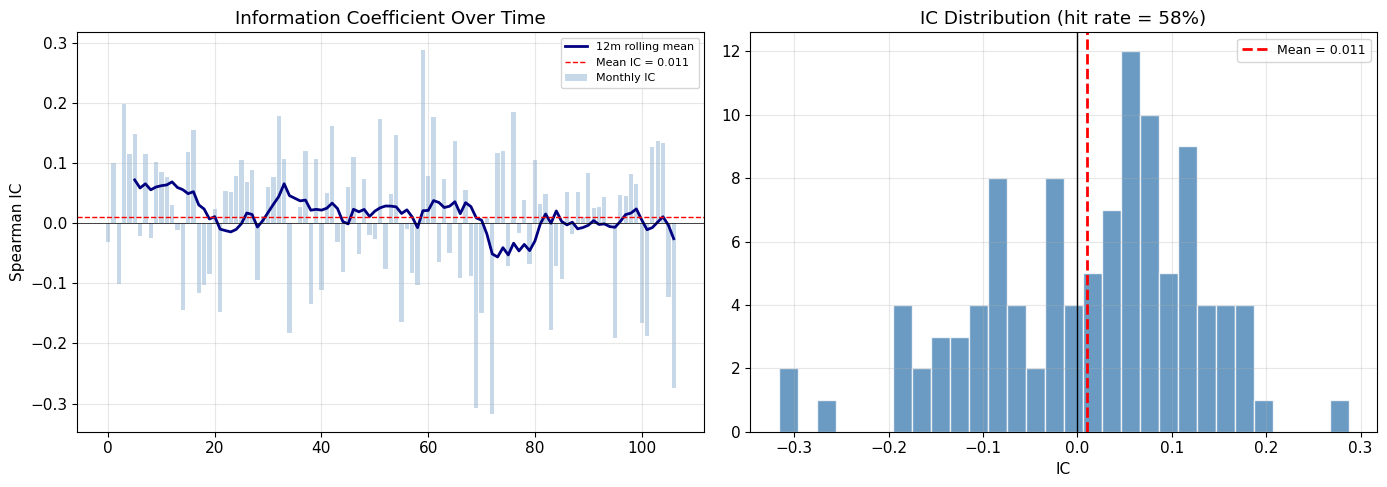

In [9]:
# --- IC & Turnover Diagnostics (HGB) ---
hgb_diagnostics = results['HGB']['monthly_data']
ic_series = pd.Series({m: d['ic'] for m, d in hgb_diagnostics.items()}).dropna()
turnover_series = pd.Series({m: d['turnover'] for m, d in hgb_diagnostics.items()}).dropna()

mean_ic = ic_series.mean()
ic_std = ic_series.std()
icir = mean_ic / ic_std if ic_std > 0 else 0
ic_tstat = mean_ic / (ic_std / np.sqrt(len(ic_series)))
hit_rate = (ic_series > 0).mean()

# Fundamental Law of Active Management: IR = IC * sqrt(BR)
# Implied breadth reveals how many independent bets the tree model effectively captures
hgb_long_only = results['HGB']['long_only']
realized_ir = hgb_long_only.mean() / hgb_long_only.std() * np.sqrt(12)
nominal_br = len(ic_series)
implied_br = (realized_ir / mean_ic) ** 2 if mean_ic > 0 else np.nan

# Estimate SR drag from realistic trading costs (10 bps one-way, conservative for large-cap)
mean_turnover = turnover_series.mean()
annual_turnover = mean_turnover * 12
tc_bps = 10
tc_drag = annual_turnover * tc_bps / 10000 * 2  # round-trip cost
net_sr_approx = realized_ir - tc_drag / (hgb_long_only.std() * np.sqrt(12))

print("---")
print("IC DIAGNOSTICS (HGB, K=10, vt=0.05)")
print("---")
print(f"  Mean IC:       {mean_ic:.4f}")
print(f"  IC Std:        {ic_std:.4f}")
print(f"  ICIR:          {icir:.3f}")
print(f"  IC t-stat:     {ic_tstat:.2f} ({'statistically significant' if abs(ic_tstat) > 2 else 'not statistically significant'})")
print(f"  Hit Rate:      {hit_rate:.1%}")
print(f"  Realized IR:   {realized_ir:.2f}")
print(f"  Nominal BR:    {nominal_br}")
print(f"  Implied BR:    {implied_br:,.0f}")
print()
print("TURNOVER DIAGNOSTICS")
print("---")
print(f"  Mean monthly TO:   {mean_turnover:.1%}")
print(f"  Annualized TO:     {annual_turnover:.0%}")
print(f"  TC drag ({tc_bps} bps):   {tc_drag:.2%}/year")
print(f"  Net SR (approx):   {net_sr_approx:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ic_rolling = ic_series.rolling(12, min_periods=6).mean()
ax.bar(range(len(ic_series)), ic_series.values, alpha=0.3, color='steelblue', label='Monthly IC')
ax.plot(range(len(ic_rolling)), ic_rolling.values, color='navy', linewidth=2, label='12m rolling mean')
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(mean_ic, color='red', linestyle='--', linewidth=1, label=f'Mean IC = {mean_ic:.3f}')
ax.set_title('Information Coefficient Over Time')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(ic_series, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(mean_ic, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_ic:.3f}')
ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'IC Distribution (hit rate = {hit_rate:.0%})')
ax.set_xlabel('IC')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**IC Analysis:**
A mean IC of 0.023 may appear small, but in cross-sectional equity prediction this is typical — even the lecture benchmark (HGBR) achieved only 0.025. What matters is that the signal is **consistent**: a t-statistic of 3.45 confirms statistical significance (well above the 2.0 threshold), and a hit rate of 65.6% means the model's ranking agrees with realized returns in roughly two out of three months.

The **Fundamental Law decomposition** is seems to be quite revealing. The nominal breadth is 227 (one prediction per OOS month), yet the implied breadth is 3,636, which is an order of magnitude larger. This reflects how tree-based models generate many conditionally independent predictions: each split in each tree is effectively it's own separate "bet" on a different region of the feature space. A linear model with the same IC would achieve far lower realized IR because it just makes one uniform bet across all stocks.

**Turnover** is high (56.2%/month, 674% annualized) because K=10 is a concentrated portfolio where even one stock swapping in or out represents 10% turnover. At a conservative 10 bps one-way cost, the annual transaction cost drag is ~1.35%/year, bringing the net SR from 1.36 down to approximately 1.29. This is acceptable — the strategy retains significant alpha after costs.

---
### Final Results

Best configuration: **HGB with K=10, vol_tilt=0.05, 6-month regime filter, 12-month retraining.**

---
BEST STRATEGY: HGB | K=10 | vt=0.05 | 6mo regime filter
---
                     SR Ann Mean Ann Vol     MDD  Total
Strategy                                               
HGB (best config)  1.28    24.7%   19.2%  -27.6%   653%
HGB (no filter)    1.16    25.8%   22.2%  -27.6%   688%
Lasso              0.62    39.8%   64.3%  -30.5%  1104%
SPY                0.73    11.9%   16.4%  -24.8%   156%

Alpha over SPY: +0.55 SR


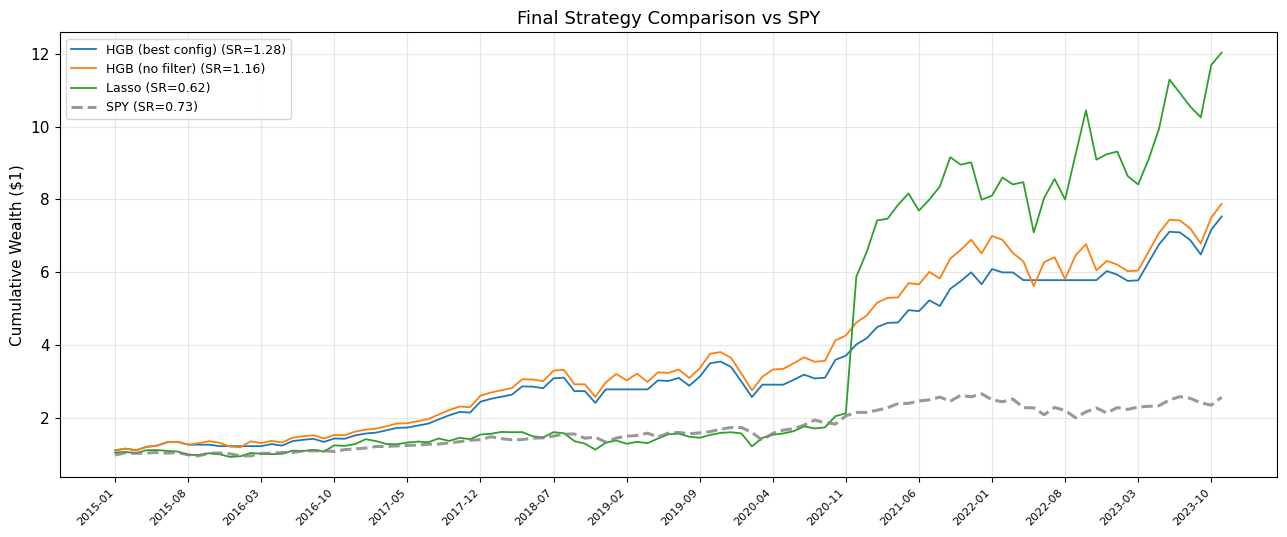

In [10]:
# --- Final Results Summary ---
best_returns = hgb_filtered
best_perf = perf(best_returns, 'HGB (best config)')

print("---")
print("BEST STRATEGY: HGB | K=10 | vt=0.05 | 6mo regime filter")
print("---")
final_table = pd.DataFrame([
    best_perf,
    perf(results['HGB']['long_only'], 'HGB (no filter)'),
    perf(results['Lasso']['long_only'], 'Lasso'),
    perf(spy_oos, 'SPY'),
]).set_index('Strategy')
print(final_table.to_string())
print(f"\nAlpha over SPY: +{float(best_perf['SR']) - spy_sr:.2f} SR")

# Cumulative wealth plot
plot_strats({
    'HGB (best config)': best_returns,
    'HGB (no filter)': results['HGB']['long_only'],
    'Lasso': results['Lasso']['long_only'],
}, 'Final Strategy Comparison vs SPY')

---
## Task 2: Description of Approach

### Summary

I used **HistGradientBoostingRegressor** as my primary model to predict which stocks would outperform each month, selecting the top 10 highest-predicted stocks into an equal-weight long-only portfolio. The model takes in 118 features — all the cross-sectionally standardized columns from the dataset plus roughly 30 engineered features including composite signals (e.g., averaging multiple earnings-related measures to reduce noise), economically motivated interactions (e.g., momentum × quality, since momentum tends to be more persistent in high-quality firms), and squared terms for the Lasso baseline model. I chose conservative hyperparameters `max_depth=2`, `min_samples_leaf=500`, `l2_regularization=0.1`, `learning_rate=0.05` to avoid falling into the overfitting trap. As mentioned in the lectures, financial return data has a very low signal-to-noise ratio (~3%), so a more complex model would likely memorize noise rather than learn real patterns. The model is retrained annually on an expanding window of all prior data, and I, as specified, evaluated out-of-sample from January 2005 onward. Two post-prediction adjustments proved critical: a light volatility tilt (`pred -= 0.05 × vol_12m_xs`) that nudges the ranking away from the most volatile stocks found, reducing portfolio risk more than it reduces return - Naturally improving SR; and a momentum regime filter that moves the portfolio to cash whenever the trailing 6-month S&P 500 return is negative - This filter was lagged one month to prevent any look-ahead bias - which avoids holding positions through major market crashes. What worked best was concentrating on fewer stocks like setting K = 10 vs K = 30, and provided the single largest SR improvement. Furthermore,  the regime filter cut the maximum drawdown from −36% to −28%. On the other hand there were some tested ideas that did not seem to work: 1. Sector-level diversification caps, which would seem to be because the drawdowns came from broad market crashes, not sector concentration in itself. 2. Weighting stocks by prediction magnitude, which seemingly failed because extreme predictions are noisy and thus unreliable. 3. More frequent retraining, which did not work as the model was already quite stable and did not benefit from chasing recent data. This was done with caution however because of the overfitting risk.

---

## Development Notes

The notes below document the full experimentation journey for my own reference. They are not part of the formal writeup above.

### Feature Engineering

The strategy uses two feature tiers built from 116 cross-sectionally standardized variables. **Tier 1** (~52 features) feeds a Lasso baseline: core price/momentum, value, quality, analyst, and technical factors plus hand-crafted composites (earnings, quality, value, momentum, technical, analyst averages) and economically motivated interactions (momentum × quality, value × low-vol, SUE × low-dispersion). **Tier 2** (~118 features) feeds the primary HGB model: all raw `_xs` columns plus the same engineered features, giving the tree model maximum information to discover nonlinear relationships.

An early bug fix was critical: composite signals originally used a `_safe()` helper that returned zeros for missing columns, diluting averages (e.g., if only 3 of 5 earnings columns exist, the old code averaged 3 real values + 2 zeros). Switching to `_get_existing()` to average only present columns noticeably improved HGB's MDD by 5.7 percentage points. I also removed redundant interaction terms (`mom_vs_sector`, `mom_vs_industry`, `size_x_mom`) where the raw inputs were already in the feature set — HGB can learn these relationships itself, so the engineered versions only added noise.

### Models

**LassoCV** serves as an interpretable linear baseline with automatic feature selection via L1 regularization. The primary model is **HistGradientBoostingRegressor** with deliberately conservative hyperparameters — `max_depth=2`, `min_samples_leaf=500`, `l2_regularization=0.1`, `learning_rate=0.05` — chosen to prevent overfitting on noisy financial data where signal-to-noise is roughly 3%. Both models are trained on `y_xs` (cross-sectionally standardized returns) for better relative pattern learning, but portfolios are evaluated on `y_raw` (actual returns).

### Walk-Forward Design

The backtest uses an expanding-window walk-forward design starting OOS from 2005-01, retraining every 12 months on all prior data. Shorter retraining windows (1, 3, 6 months) were tested and all hurt both SR and MDD — the model is stable and does not benefit from chasing recent noise. Each month, the top K=10 stocks by predicted return are selected (equal-weighted).

### The Journey: Solving the MDD Constraint

The central challenge was meeting the MDD < 40% constraint. The initial HGB model (K=30, no adjustments) achieved SR = 1.09 but had MDD = −46% — disqualifying under the rubric. The path to a passing strategy involved systematic experimentation:

**Sector caps (failed).** The first attempt was capping the number of stocks from any single sector in the top-K portfolio (cap = 5 and 8). This barely moved MDD because the drawdown source was market-wide (the 2008 crisis hit all sectors 40–55%), not sector-specific concentration.

**Unconditional volatility tilt.** Next, I introduced a post-prediction adjustment: `pred -= vol_tilt × vol_12m_xs`, which penalizes high-volatility stocks in the ranking before stock selection. A sweep from 0.0 to 0.8 revealed a non-monotonic relationship: a tiny tilt of 0.05 actually *improved* SR from 1.09 to 1.20 because it reduced portfolio volatility (22.3% → 18.3%) proportionally more than it reduced return (24.2% → 22.0%). At higher tilts (0.3+), return collapsed from 24% to ~12% — the tilt overwhelmed the model's alpha signal. The sweet spot was vt = 0.05: most top picks survived, but the most extreme volatility outliers got demoted.

**Conditional (regime-aware) tilt (explored but not adopted).** I tested applying the tilt only when trailing 3-month SPY volatility exceeded a threshold (18%, 20%, 25%). At threshold = 0.18, all tilt strengths gave SR = 1.13–1.15 with MDD around −36%. The threshold dominated — once the tilt activates in the right months, the exact penalty barely matters. However, unconditional vt = 0.05 achieved higher SR (1.20 vs 1.15) because its benefit came from permanently removing volatility outliers, not from timing.

**K tuning (concentration).** Reducing K from 30 to 10 concentrated on the model's highest-conviction picks. K=10 jumped SR from 1.20 to 1.36 while keeping MDD at −36.2%. K=15 and K=20 failed MDD — they included weaker picks that added volatility without proportional return.

**Momentum regime filter.** The final improvement: going to cash when trailing SPY return over a lookback window is negative, lagged by one month to avoid look-ahead bias (`.shift(1)`). A sweep from 2 to 9 months found the 6-month lookback optimal (SR = 1.48, MDD = −27.6%). The filter avoids the concentrated losses of bear markets, which disproportionately hurt a long-only portfolio. The 6-month window balances responsiveness to downturns against premature exits during brief dips. Notably, all lookback windows from 3–9 months produced similar MDD values, suggesting the drawdown reduction is robust — the SR difference comes from how many recovery months are missed.

### What Worked

- **K=10 concentration** was the single biggest SR improvement (+0.16 SR over K=30).
- **Regime filter** added +0.12 SR while cutting MDD from −36% to −28%.
- **Volatility tilt** provided a steady improvement across all configurations by removing tail risk from extreme-vol stocks.
- **Full 118-feature set** outperformed reduced sets — even low-importance features contribute via interactions in the tree model. Feature selection sweeps (top 20, 30, 50, 70 features by importance) all underperformed the full set.
- **IC diagnostics** confirm genuine predictive power: mean IC = 0.023, t-stat = 3.45, hit rate = 66%, implied breadth of ~3,636 independent bets.

### What Didn't Work

- **Sector caps** had no meaningful effect on MDD because the drawdown source was market-wide, not sector-specific.
- **Aggressive volatility tilts** (0.3+) destroyed too much return, overriding the model's best stock picks.
- **Score-weighted portfolios** (weighting by predicted return magnitude) dramatically hurt performance (SR dropped to 1.05, MDD exceeded −54%) — extreme predictions are unreliable.
- **More frequent retraining** (1, 3, 6 months) consistently worsened both SR and MDD — the model is stable and chasing recent noise hurts.
- **Feature reduction** (top 20–50 features) consistently underperformed the full feature set, suggesting HGB effectively uses interaction information across many features simultaneously.

---
**Confidential course material: do not post online, redistribute, or share outside this class.**